# FintrackAI EDA Notebook

This notebook is dedicated to exploratory data analysis (EDA) for:
- `users_data.csv`
- `cards_data.csv`
- `transactions_data.csv`
- `mcc_codes.json`

Focus areas:
1. Data quality and schema checks
2. Distribution shape (skewness, kurtosis, tails)
3. Outliers and value ranges
4. Temporal patterns and seasonality
5. User/card/category behavior patterns

Fraud analysis is intentionally excluded.

In [16]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path('.')
MAX_TX_ROWS = 2_000_000  # increase if your machine can handle more
SEED = 42


In [2]:
def to_money(series):
    return (series.astype(str)
            .str.replace('$', '', regex=False)
            .str.replace(',', '', regex=False)
            .astype(float))

users = pd.read_csv(DATA_DIR / 'users_data.csv')
cards = pd.read_csv(DATA_DIR / 'cards_data.csv')

usecols = ['id','date','client_id','card_id','amount','merchant_id','merchant_city','merchant_state','mcc','errors']
chunks = []
rows = 0
for ch in pd.read_csv(DATA_DIR / 'transactions_data.csv', usecols=usecols, chunksize=300_000):
    chunks.append(ch)
    rows += len(ch)
    if rows >= MAX_TX_ROWS:
        break
tx = pd.concat(chunks, ignore_index=True)

users['yearly_income'] = to_money(users['yearly_income'])
users['total_debt'] = to_money(users['total_debt'])
users['monthly_income'] = users['yearly_income'] / 12
cards['credit_limit'] = to_money(cards['credit_limit'])

tx['amount'] = to_money(tx['amount'])
tx['spend'] = tx['amount'].clip(lower=0.0)
tx['date'] = pd.to_datetime(tx['date'], errors='coerce')
tx['month'] = tx['date'].dt.to_period('M').dt.to_timestamp()
tx['hour'] = tx['date'].dt.hour
tx['weekday'] = tx['date'].dt.day_name()

with open(DATA_DIR / 'mcc_codes.json') as f:
    mcc_map = json.load(f)

print('users:', users.shape)
print('cards:', cards.shape)
print('transactions sample:', tx.shape)
tx.head()


users: (2000, 15)
cards: (6146, 13)
transactions sample: (2100000, 14)


,id,date,client_id,card_id,amount,merchant_id,merchant_city,merchant_state,mcc,errors,spend,month,hour,weekday
0,7475327,2010-01-01 00:01:00,1556,2972,-77.00,59935,Beulah,ND,5499,NaN,0.00,2010-01-01,0,Friday
1,7475328,2010-01-01 00:02:00,561,4575,14.57,67570,Bettendorf,IA,5311,NaN,14.57,2010-01-01,0,Friday
2,7475329,2010-01-01 00:02:00,1129,102,80.00,27092,Vista,CA,4829,NaN,80.00,2010-01-01,0,Friday
3,7475331,2010-01-01 00:05:00,430,2860,200.00,27092,Crown Point,IN,4829,NaN,200.00,2010-01-01,0,Friday
4,7475332,2010-01-01 00:06:00,848,3915,46.41,13051,Harwood,MD,5813,NaN,46.41,2010-01-01,0,Friday


## 1) Schema + Data Quality

In [3]:
print('Users dtypes')
display(users.dtypes)
print('Cards dtypes')
display(cards.dtypes)
print('Transactions dtypes')
display(tx.dtypes)

quality = pd.DataFrame({
    'dataset': ['users','cards','transactions'],
    'rows': [len(users), len(cards), len(tx)],
    'cols': [users.shape[1], cards.shape[1], tx.shape[1]],
    'duplicate_rows': [users.duplicated().sum(), cards.duplicated().sum(), tx.duplicated().sum()]
})
display(quality)

print('Missingness (top) - users')
display(users.isna().mean().sort_values(ascending=False).head(10))
print('Missingness (top) - cards')
display(cards.isna().mean().sort_values(ascending=False).head(10))
print('Missingness (top) - transactions')
display(tx.isna().mean().sort_values(ascending=False).head(10))


Users dtypes


id                     int64
current_age            int64
retirement_age         int64
birth_year             int64
birth_month            int64
gender                object
address               object
latitude             float64
longitude            float64
per_capita_income     object
yearly_income        float64
total_debt           float64
credit_score           int64
num_credit_cards       int64
monthly_income       float64
dtype: object

Cards dtypes


id                         int64
client_id                  int64
card_brand                object
card_type                 object
card_number                int64
expires                   object
cvv                        int64
has_chip                  object
num_cards_issued           int64
credit_limit             float64
acct_open_date            object
year_pin_last_changed      int64
card_on_dark_web          object
dtype: object

Transactions dtypes


...

id                   0.0
current_age          0.0
retirement_age       0.0
birth_year           0.0
birth_month          0.0
gender               0.0
address              0.0
latitude             0.0
longitude            0.0
per_capita_income    0.0
dtype: float64

Missingness (top) - cards


id                  0.0
client_id           0.0
card_brand          0.0
card_type           0.0
card_number         0.0
expires             0.0
cvv                 0.0
has_chip            0.0
num_cards_issued    0.0
credit_limit        0.0
dtype: float64

Missingness (top) - transactions


errors            0.984230
merchant_state    0.108552
id                0.000000
date              0.000000
client_id         0.000000
card_id           0.000000
amount            0.000000
merchant_id       0.000000
merchant_city     0.000000
mcc               0.000000
dtype: float64

## 2) Distribution Analysis (Skew, Tails, Outliers)

,metric,value
0,mean,48.788168
1,median,29.350000
2,std,74.950509
3,min,0.000000
4,p90,106.611000
5,p95,147.750000
6,p99,324.410100
7,max,6820.200000
8,skewness,8.964963
9,kurtosis,225.331765


Interpretation: spend distribution is right-skewed with heavy-tailed.


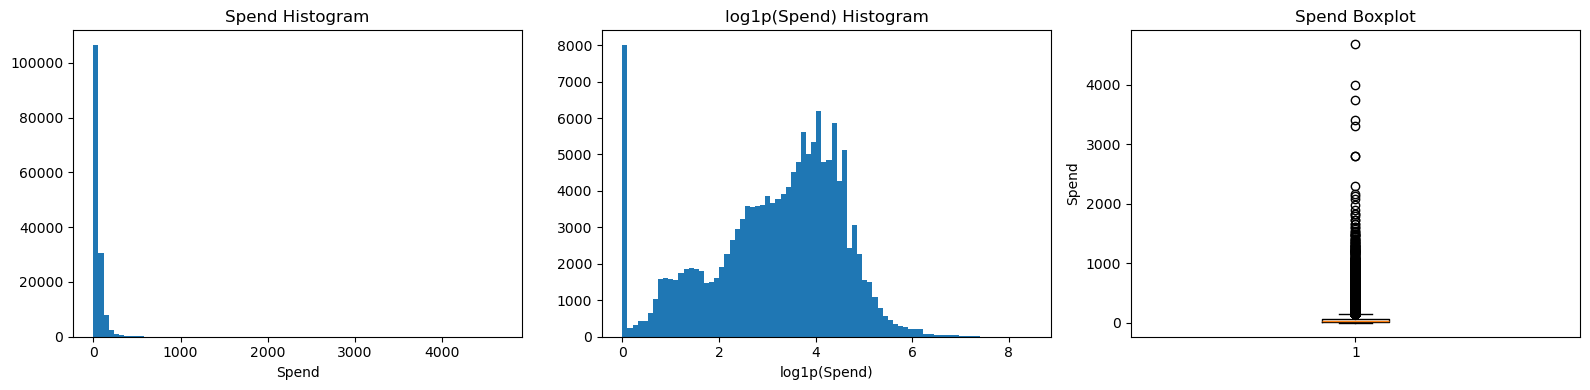

In [10]:
s = tx['spend'].dropna()
q1, q3 = s.quantile(0.25), s.quantile(0.75)
iqr = q3 - q1
lower = max(0.0, q1 - 1.5 * iqr)
upper = q3 + 1.5 * iqr
outlier_mask = (s < lower) | (s > upper)

dist = pd.DataFrame({
    'metric': ['mean','median','std','min','p90','p95','p99','max','skewness','kurtosis','outlier_rate'],
    'value': [
        s.mean(), s.median(), s.std(), s.min(),
        s.quantile(0.9), s.quantile(0.95), s.quantile(0.99), s.max(),
        s.skew(), s.kurtosis(), outlier_mask.mean()
    ]
})
display(dist)

shape = 'right-skewed' if s.skew() > 0.5 else ('left-skewed' if s.skew() < -0.5 else 'roughly symmetric')
tails = 'heavy-tailed' if s.kurtosis() > 3 else 'light/moderate tails'
print(f'Interpretation: spend distribution is {shape} with {tails}.')

sample = s.sample(min(len(s), 150_000), random_state=SEED)
fig, ax = plt.subplots(1, 3, figsize=(16,4))
ax[0].hist(sample, bins=80)
ax[0].set_title('Spend Histogram')
ax[0].set_xlabel('Spend')

ax[1].hist(np.log1p(sample), bins=80)
ax[1].set_title('log1p(Spend) Histogram')
ax[1].set_xlabel('log1p(Spend)')

ax[2].boxplot(sample.values, vert=True)
ax[2].set_title('Spend Boxplot')
ax[2].set_ylabel('Spend')

plt.tight_layout()
plt.show()


## 3) Temporal EDA (Trend, Seasonality, Intraday Patterns)

Monthly volatility (std of pct_change): 0.2241


,month_num,avg_spend
7,8,5328491.965
6,7,5299736.230
11,12,5215337.380
9,10,5199757.080
4,5,5195479.390
2,3,5164005.885
5,6,5160167.790
0,1,5055101.395
3,4,5048833.475
10,11,5018560.790


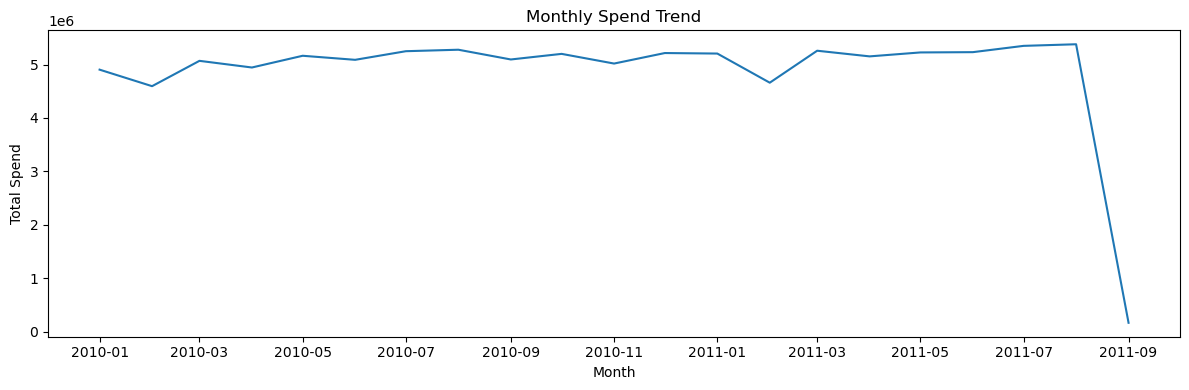

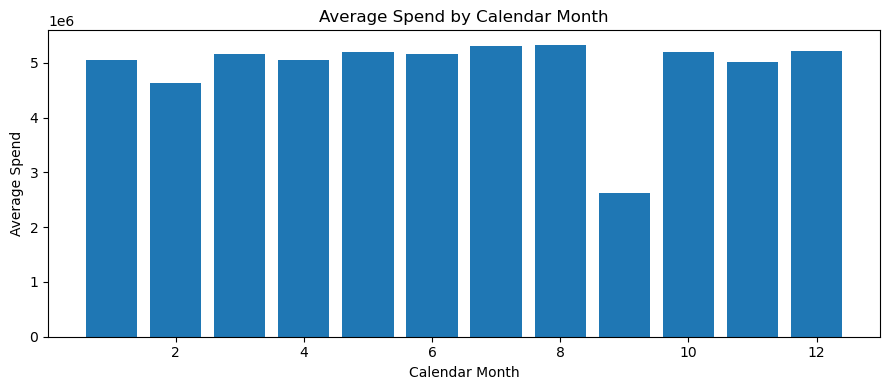

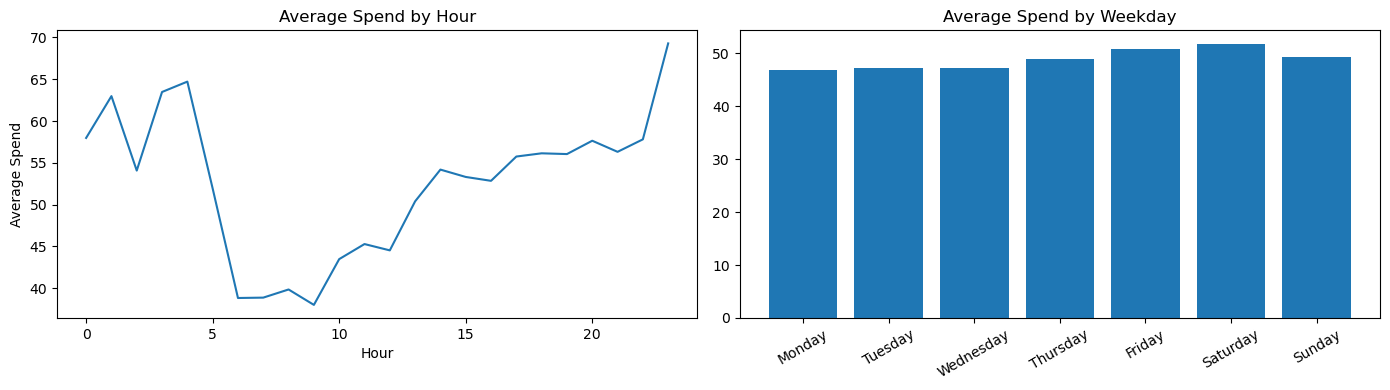

In [11]:
monthly_total = tx.groupby('month', as_index=False)['spend'].sum().sort_values('month')
monthly_total['pct_change'] = monthly_total['spend'].pct_change()
monthly_total['month_num'] = monthly_total['month'].dt.month
seasonality = monthly_total.groupby('month_num', as_index=False)['spend'].mean().rename(columns={'spend':'avg_spend'})

print('Monthly volatility (std of pct_change):', round(monthly_total['pct_change'].std(skipna=True), 4))
display(seasonality.sort_values('avg_spend', ascending=False))

plt.figure(figsize=(12,4))
plt.plot(monthly_total['month'], monthly_total['spend'])
plt.title('Monthly Spend Trend')
plt.xlabel('Month')
plt.ylabel('Total Spend')
plt.tight_layout()
plt.show()

plt.figure(figsize=(9,4))
plt.bar(seasonality['month_num'], seasonality['avg_spend'])
plt.title('Average Spend by Calendar Month')
plt.xlabel('Calendar Month')
plt.ylabel('Average Spend')
plt.tight_layout()
plt.show()

hourly = tx.groupby('hour', as_index=False)['spend'].mean()
weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
weekday = tx.groupby('weekday', as_index=False)['spend'].mean()
weekday['weekday'] = pd.Categorical(weekday['weekday'], categories=weekday_order, ordered=True)
weekday = weekday.sort_values('weekday')

fig, ax = plt.subplots(1,2, figsize=(14,4))
ax[0].plot(hourly['hour'], hourly['spend'])
ax[0].set_title('Average Spend by Hour')
ax[0].set_xlabel('Hour')
ax[0].set_ylabel('Average Spend')

ax[1].bar(weekday['weekday'].astype(str), weekday['spend'])
ax[1].set_title('Average Spend by Weekday')
ax[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


## 4) Customer + Card Behavior EDA

In [13]:
monthly_user = tx.groupby(['client_id', 'month'], as_index=False)['spend'].sum()
user_agg = (
    monthly_user.groupby('client_id', as_index=False)
    .agg(
        avg_monthly_spend=('spend', 'mean'),
        std_monthly_spend=('spend', 'std'),
        max_monthly_spend=('spend', 'max'),
        active_months=('spend', 'count')
    )
)
user_agg.columns = ['client_id','avg_monthly_spend','std_monthly_spend','max_monthly_spend','active_months']

uc = users[['id','monthly_income','credit_score','total_debt','num_credit_cards']].rename(columns={'id':'client_id'})
user_profile = uc.merge(user_agg, on='client_id', how='left')

print('User-level summary')
display(user_profile[['monthly_income','credit_score','total_debt','num_credit_cards','avg_monthly_spend','std_monthly_spend']].describe())

corr_cols = ['monthly_income','credit_score','total_debt','num_credit_cards','avg_monthly_spend','std_monthly_spend']
corr = user_profile[corr_cols].corr(numeric_only=True)
display(corr)

card_use = tx.groupby('card_id', as_index=False)['spend'].sum().rename(columns={'spend':'total_card_spend'})
card_profile = cards[['id','client_id','card_type','card_brand','credit_limit']].rename(columns={'id':'card_id'})
card_view = card_profile.merge(card_use, on='card_id', how='left')
display(card_view.groupby('card_type', as_index=False)['total_card_spend'].mean().sort_values('total_card_spend', ascending=False))


User-level summary


,monthly_income,credit_score,total_debt,num_credit_cards,avg_monthly_spend,std_monthly_spend
count,2000.000000,2000.000000,2000.000000,2000.000000,1156.000000,1153.000000
mean,3809.656833,709.734500,63709.694000,3.073000,4313.651561,1324.510140
std,1916.051288,67.221949,52254.453421,1.637379,2599.338508,700.008444
min,0.083333,480.000000,0.000000,1.000000,342.962727,80.424426
25%,2734.875000,681.000000,23986.750000,2.000000,2631.163571,869.859016
50%,3395.375000,711.500000,58251.000000,3.000000,3663.142857,1189.929654
75%,4391.541667,753.000000,89070.500000,4.000000,5410.694405,1609.883603
max,25584.833333,850.000000,516263.000000,9.000000,25230.354286,5926.455502


,monthly_income,credit_score,total_debt,num_credit_cards,avg_monthly_spend,std_monthly_spend
monthly_income,1.000000,0.000167,0.550641,-0.032877,0.446271,0.538034
credit_score,0.000167,1.000000,-0.104537,0.237935,-0.043383,-0.056245
total_debt,0.550641,-0.104537,1.000000,-0.217940,0.169590,0.231502
num_credit_cards,-0.032877,0.237935,-0.217940,1.000000,0.081266,0.058482
avg_monthly_spend,0.446271,-0.043383,0.169590,0.081266,1.000000,0.897642
std_monthly_spend,0.538034,-0.056245,0.231502,0.058482,0.897642,1.000000


,card_type,total_card_spend
0,Credit,37719.786505
1,Debit,33452.486056
2,Debit (Prepaid),12465.943486


## 5) Merchant Category (MCC) EDA

,mcc_str,category,spend
43,4829,Money Transfer,8603920.00
59,5541,Service Stations,8320730.23
56,5411,"Grocery Stores, Supermarkets",6475589.11
57,5499,Miscellaneous Food Stores,6084790.73
53,5300,Wholesale Clubs,6054972.77
74,5912,Drug Stores and Pharmacies,5649740.65
45,4900,"Utilities - Electric, Gas, Water, Sanitary",4418501.98
55,5311,Department Stores,4365836.89
69,5812,Eating Places and Restaurants,4190624.27
42,4814,Telecommunication Services,3942653.07


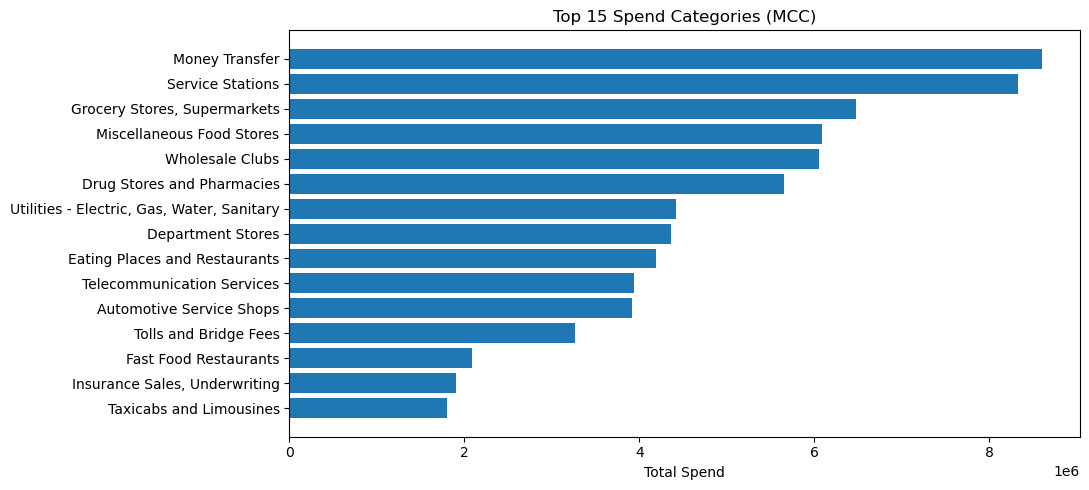

Category concentration (HHI): 0.04


In [14]:
mcc_spend = tx.groupby('mcc', as_index=False)['spend'].sum().sort_values('spend', ascending=False)
mcc_spend['mcc_str'] = mcc_spend['mcc'].astype('Int64').astype(str)
mcc_spend['category'] = mcc_spend['mcc_str'].map(mcc_map).fillna('Unknown')
top_mcc = mcc_spend.head(15).copy()
display(top_mcc[['mcc_str','category','spend']])

plt.figure(figsize=(11,5))
plt.barh(top_mcc['category'][::-1], top_mcc['spend'][::-1])
plt.title('Top 15 Spend Categories (MCC)')
plt.xlabel('Total Spend')
plt.tight_layout()
plt.show()

# Category concentration (how concentrated spending is)
share = (mcc_spend['spend'] / mcc_spend['spend'].sum()).reset_index(drop=True)
hhi = float((share ** 2).sum())
print('Category concentration (HHI):', round(hhi, 4))


## 6) EDA Conclusions Template

In [15]:
# Fill this after running all cells.
conclusions = {
    'data_quality': '',
    'distribution_shape': '',
    'outlier_behavior': '',
    'time_patterns': '',
    'user_segments_hint': '',
    'modeling_implications': ''
}
conclusions


{'data_quality': '',
 'distribution_shape': '',
 'outlier_behavior': '',
 'time_patterns': '',
 'user_segments_hint': '',
 'modeling_implications': ''}